## Langgraph 를 활용한 Agentic RAG

In [1]:
# 법률 문서 활용 - 사내 문서를 활용하여 rag를 구축할 경우
# 법률이 사내 문서와 구조가 비슷하기 때문에, 현업 프로젝트에 도움이 될 것 같다.

In [2]:
# 우리가 필요한 건 위 “제55조(세율)” 표 → 이걸 가지고 세금을 계산하는 에이전트를 만든다

In [3]:
# %pip install -U langchain-community pypdf
# %pip install langchain-community langchain-text-splitters

In [4]:
# 문서를 통으로 LLM에 전달을 하면 토큰이 초과되어 답변 생성이 안되는 경우도 있음
# 토큰 초과가 안된다고 해도 (답변생성이 가능하다고 해도), 토큰을 너무 많이 쓰기 때문에
# 비용이나 시간에서 불이익이 있다

# 필요없는 정보까지 포함해서 넘 ㅜ많은 콘텍스트까지 제공 -> Hallu 상승
# 꼭 필요한 부분만 넘겨줘야 한다.

# 그래서 RAG를 구성하려면 먼저, Doc가 있으면 불러와서 적당한 사이즈로 쪼갠 다음에,LLM에 전달하는게 적절하다

In [5]:
# pdf 파싱

from langchain_community.document_loaders import PyPDFLoader


pdf_file_path = '../documents/income_tax.pdf'

# 로더 생성
loader = PyPDFLoader(
    file_path=pdf_file_path
    )

# Lazy Load
pages = []
async for page in loader.alazy_load():
    pages.append(page)


C:\Users\Yurim Park\AppData\Local\Temp\ipykernel_60556\853110872.py:3: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import PyPDFLoader


In [6]:
pages  # 쪽수별로 나뉨

[Document(metadata={'producer': 'iText 2.1.7 by 1T3XT', 'creator': 'PyPDF', 'creationdate': '2025-01-10T10:55:01+09:00', 'moddate': '2025-01-10T10:55:01+09:00', 'source': '../documents/income_tax.pdf', 'total_pages': 133, 'page': 0, 'page_label': '1'}, page_content='법제처                                                            1                                                       국가법령정보센터\n소득세법\n \n소득세법\n[시행 2025. 1. 1.] [법률 제20615호, 2024. 12. 31., 일부개정]\n기획재정부 (재산세제과(양도소득세)) 044-215-4312\n기획재정부 (소득세제과(근로소득)) 044-215-4216\n기획재정부 (금융세제과(이자소득, 배당소득)) 044-215-4233\n기획재정부 (소득세제과(사업소득, 기타소득)) 044-215-4217\n       제1장 총칙 <개정 2009. 12. 31.>\n \n제1조(목적) 이 법은 개인의 소득에 대하여 소득의 성격과 납세자의 부담능력 등에 따라 적정하게 과세함으로써 조세부\n담의 형평을 도모하고 재정수입의 원활한 조달에 이바지함을 목적으로 한다.\n[본조신설 2009. 12. 31.]\n[종전 제1조는 제2조로 이동 <2009. 12. 31.>]\n \n제1조의2(정의) ① 이 법에서 사용하는 용어의 뜻은 다음과 같다. <개정 2010. 12. 27., 2014. 12. 23., 2018. 12. 31.>\n1. “거주자”란 국내에 주소를 두거나 183일 이상의 거소(居所)를 둔 개인을 말한다.\n2. “비거주자”란 거주자가 아닌 개인을 말한다.\n3. “내국법인”이란 「법인

In [7]:
pages[34]   # 세율 표는 35페이지에

# 표가 없이 바로 다름으로 넘어간다 (표 파싱이 안되었음)
# 표는 이미지로 되어있음
# 랭체인에서 기본으로 제공하는 pdfloader 는 이미지 파싱을 못하기 때문에 쓸 수 없음

#####################
## 방법
#####################
# 1. chat gpt에 pdf를 업로드를 하고 "제 55조 테이블을 파싱해주세요" 라는 프롬프트로 파싱할 수 있다
# 1-1. 모든 문서에 대해서 이렇게 일일히 전처리 하기에는 무리 (+보안 문제)

# 2. 외부 패키지를 사용하는 방법 - py-zerox
# 2-1. LLM을 활용해서 OCR을 돌려서 이미지를 파싱하는 방법

Document(metadata={'producer': 'iText 2.1.7 by 1T3XT', 'creator': 'PyPDF', 'creationdate': '2025-01-10T10:55:01+09:00', 'moddate': '2025-01-10T10:55:01+09:00', 'source': '../documents/income_tax.pdf', 'total_pages': 133, 'page': 34, 'page_label': '35'}, page_content='법제처                                                            35                                                       국가법령정보센터\n소득세법\n[전문개정 2009. 12. 31.]\n \n제54조(종합소득공제 등의 배제) ① 분리과세이자소득, 분리과세배당소득, 분리과세연금소득과 분리과세기타소득만이\n있는 자에 대해서는 종합소득공제를 적용하지 아니한다. <개정 2013. 1. 1.>\n② 제70조제1항, 제70조의2제2항 또는 제74조에 따라 과세표준확정신고를 하여야 할 자가 제70조제4항제1호에 따\n른 서류를 제출하지 아니한 경우에는 기본공제 중 거주자 본인에 대한 분(分)과 제59조의4제9항에 따른 표준세액공\n제만을 공제한다. 다만, 과세표준확정신고 여부와 관계없이 그 서류를 나중에 제출한 경우에는 그러하지 아니하다.\n<개정 2013. 1. 1., 2014. 1. 1.>\n③ 제82조에 따른 수시부과 결정의 경우에는 기본공제 중 거주자 본인에 대한 분(分)만을 공제한다.\n[전문개정 2009. 12. 31.]\n[제목개정 2014. 1. 1.]\n \n제54조의2(공동사업에 대한 소득공제 등 특례) 제51조의3 또는 「조세특례제한법」에 따른 소득공제를 적용하거나 제\n59조의3에 따른 세액공제를 적용하는 경우 제43조제3항에 따라 소득금액이 주된 공동사업자의 소득금액에 합산과\n세되는

In [8]:
# %pip install -q py-zerox

In [9]:
# py-zerox 는 litellm 이라는 wrapper 를 사용해서 oCR을 돌리기 때문에
# 모델명과 환경변수를 주면 gemini, gpt, claude 등등 상용 LLM을 써서 파싱이 가능하다

In [10]:
# 노트북에서 asyncio를 사용하기 위해 nest_asyncio를 설치
# asyncio를 돌릴 때 event loop 가 없어야 되는데 노트북에서 기본적으로 돌리고 있는게 있어서 에러

# nest_asyncio 설치 후 아래 셀 실행
# %pip install -q nest_asyncio

In [11]:
import nest_asyncio

nest_asyncio.apply()

In [12]:
from dotenv import load_dotenv

load_dotenv()

True

- 아래 코드는 gpt 비용 청구되는 셀이므로 주석

In [13]:
# from pyzerox import zerox
# import os
# import json
# import asyncio


# ### Model Setup (Use only Vision Models) Refer: https://docs.litellm.ai/docs/providers ###
# # 여기서는 GPT 를 연결하여 성능이 좋은 비전 모델을 활용한다. 
# model = 'gpt-4.1'

# ## placeholder for additional model kwargs which might be required for some models
# kwargs = {}

# ## system prompt to use for the vision model
# custom_system_prompt = None

# # Define main async entrypoint
# async def main():
#     file_path = "../documents/income_tax.pdf" ## local filepath and file URL supported

#     ## process only some pages or all
#     select_pages = None  ## None for all, but could be int or list(int) page numbers (1 indexed)

#     output_dir = "../documents/output_docs" ## directory to save the consolidated markdown file
#     result = await zerox(file_path=file_path, model=model, output_dir=output_dir,
#                         custom_system_prompt=custom_system_prompt,select_pages=select_pages, **kwargs)
    
#     return result


# # run the main function:
# result = asyncio.run(main())

# # print markdown result
# print(result)

### MarkdownLoader 로 md 파일 로드

In [14]:
# zerox를 활용한 전처리 후 생성된 마크다운 파일을 로드 해야 함
# unstructured 패키지를 설치
# UnstructuredMarkdownLoader를 사용해 전처리된 데이터를 확인한다. 

In [15]:
# unstructured는 문서파싱으로 유명한 회사
# nltk 는 nlp 패키지 : 랭체인에서 같이 쓰는걸 권장

In [16]:
# %pip install -q "unstructured[md]" nltk

In [17]:
# loader활용 시 테이블 구조가 사라진다

from langchain_community.document_loaders import UnstructuredMarkdownLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter


# langchain 의 text splitter : 
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size = 1500,
    chunk_overlap = 100,
    separators=['\n\n', '\n']
)


# pdfLoader 와의 차이점: 큰 문서를 pages 단위로 쪼갠다
# loader.load() : 문서를 통으로 로드해줌 -> split을 별도로 진행해야 함
loader = UnstructuredMarkdownLoader(
    "../documents/output_docs/income_tax.md", 
    mode="elements", 
    strategy="fast")

# data = loader.load()
document_list = loader.load_and_split(text_splitter=text_splitter)  # load() 대신에 load_and_split을 해준다

In [18]:
document_list

[Document(metadata={'source': '../documents/output_docs/income_tax.md', 'category_depth': 0, 'languages': ['kor'], 'file_directory': '../documents/output_docs', 'filename': 'income_tax.md', 'filetype': 'text/markdown', 'last_modified': '2026-09-27T16:08:43', 'category': 'Title', 'element_id': '463e9d3f907f4764689568308ab7f8bf'}, page_content='소득세법'),
 Document(metadata={'source': '../documents/output_docs/income_tax.md', 'languages': ['kor'], 'file_directory': '../documents/output_docs', 'filename': 'income_tax.md', 'filetype': 'text/markdown', 'last_modified': '2026-09-27T16:08:43', 'parent_id': '463e9d3f907f4764689568308ab7f8bf', 'category': 'UncategorizedText', 'element_id': '0f1faf95d834dd59bf41e70a4c8c5f2c'}, page_content='[시행 2025. 1. 1.] [법률 제20615호, 2024. 12. 31., 일부개정] 기획재정부 (재산세제과(양도소득세)) 044-215-4312 기획재정부 (소득세제과(근로소득)) 044-215-4216 기획재정부 (금융세제과(이자소득, 배당소득)) 044-215-4233 기획재정부 (소득세제과(사업소득, 기타소득)) 044-215-4217'),
 Document(metadata={'source': '../documents/output_docs/income_

In [19]:
# 위 셀까지 실행
## 마크다운은 잘 들어와서 표 내용은 잘 들어왔는데, 표가 잘린 형태 (줄글 \n 로만 들어온다)
## 마크다운을 쓰면 답변이 잘 나올 수도 있지만 정확한 컨테스트를 전달하는 건 아님

## 마크다운 -> txt로 변환한 후, load & split을 해야 함

In [20]:
# 필요 패키지 설치
# %pip install -q markdown html2text beautifulsoup4

- .md 파일을 .txt 파일로 변환

In [21]:
# .txt 파일로 변환

import markdown
from bs4 import BeautifulSoup

text_path = '../documents/output_docs/income_tax.txt'  # 결과
markdown_path = '../documents/output_docs/income_tax.md' # 인풋

# 마크다운 파일을 읽어옵니다
with open(markdown_path, 'r', encoding='utf-8') as md_file:
    md_content = md_file.read()

# 마크다운 콘텐츠를 HTML로 변환합니다
html_content = markdown.markdown(md_content)

# HTML 콘텐츠를 파싱하여 텍스트만 추출합니다
soup = BeautifulSoup(html_content, 'html.parser')
text_content = soup.get_text()

# 추출한 텍스트를 텍스트 파일로 저장합니다
with open(text_path, 'w', encoding='utf-8') as txt_file:
    txt_file.write(text_content)

print("Markdown converted to plain text successfully!")

Markdown converted to plain text successfully!


- Langchain 의 TxtLoader 로 .txt 파일 로딩

In [22]:
from langchain_community.document_loaders import TextLoader

loader = TextLoader(text_path, encoding='utf-8')
document_list = loader.load_and_split(text_splitter=text_splitter)

In [23]:
document_list

[Document(metadata={'source': '../documents/output_docs/income_tax.txt'}, page_content='소득세법\n[시행 2025. 1. 1.] [법률 제20615호, 2024. 12. 31., 일부개정]\n기획재정부 (재산세제과(양도소득세)) 044-215-4312\n기획재정부 (소득세제과(근로소득)) 044-215-4216\n기획재정부 (금융세제과(이자소득, 배당소득)) 044-215-4233\n기획재정부 (소득세제과(사업소득, 기타소득)) 044-215-4217'),
 Document(metadata={'source': '../documents/output_docs/income_tax.txt'}, page_content='제1장 총칙 <개정 2009. 12. 31.>\n제1조(목적)\n이 법은 개인의 소득에 대하여 소득의 성격과 납세자의 부담능력 등에 따라 적정하게 과세함으로써 조세부담의 형평을 도모하고 재정수입의 원활한 조달에 이바지함을 목적으로 한다.\n[본조신설 2009. 12. 31.]\n[종전 제1조는 제2조로 이동 <2009. 12. 31.>]\n제2조의2(정의)\n① 이 법에서 사용하는 용어의 뜻은 다음과 같다. <개정 2010. 12. 27., 2014. 12. 23., 2018. 12. 31.>\n1. "거주자"란 국내에 주소를 두거나 183일 이상의 거소(居所)를 둔 개인을 말한다.\n2. "비거주자"란 거주자가 아닌 개인을 말한다.\n3. "내국법인"이란 「법인세법」 제2조제1호에 따른 내국법인을 말한다.\n4. "외국법인"이란 「법인세법」 제2조제3호에 따른 외국법인을 말한다.\n5. "사업자"란 사업소득이 있는 거주자를 말한다.\n② 제1항에 따른 주소·거소와 거주자·비거주자의 구분은 대통령령으로 정한다.\n[본조신설 2009. 12. 31.]\n제2조(납세의무)\n① 다음 각 호의 어느 하나에 해당하는 개인은 이 법에 따라 각각의 소득에 대한 소득세를 납부할 의무를 진다.\n1

### ChromaDB에 삽입

In [24]:
# %pip install -q langchain-chroma

In [25]:
# from langchain_openai import OpenAIEmbeddings

# embeddings = OpenAIEmbeddings(model='text-embedding-3-large')

In [26]:
from langchain_ollama import OllamaEmbeddings

# 이제 임베딩 생성에는 OPENAI_API_KEY도 필요 없고 API 비용 발생 X
embeddings = OllamaEmbeddings(
    model="bge-m3",
    base_url="http://localhost:11434"
)

In [27]:
## 벡터 스토어 생성

from langchain_chroma import Chroma


# 앞에서 준비한 문서들을 숫자 벡터로 변환한 뒤 Chroma 벡터 데이터베이스에 저장하는 로직
# 최초 DB 생성시에만 활용한다. 재실행할 경우, 문서가 중복되어 들어간다. 
vector_store = Chroma.from_documents(
    documents=document_list,
    embedding=embeddings,
    collection_name='income_tax_collection',
    persist_directory='../income_tax_collection'   # 로컬에 설정한 경로로 데이터가 남음 (DB의 역할을 한다)
)


# # 이미 생성된 db 에서 조회하는 코드
# vector_store = Chroma(
#     documents=document_list,
#     embedding=embeddings,
#     collection_name='income_tax_collection',
#     persist_directory='../income_tax_collection'   # 로컬에 설정한 경로로 데이터가 남음 (DB의 역할을 한다)
# )

In [28]:
# 중복된 문서가 있는지 확인하는 테스트 코드 - test 용 파이썬 모듈로 빼서 import 하는 방법
from collections import Counter

data = vector_store.get(include=["documents"])
documents = data["documents"]
content_counts = Counter(documents)
duplicate_groups = {
    content: count
    for content, count in content_counts.items()
    if count > 1
}

print(f"전체 레코드 수: {len(documents)}")
print(f"고유 문서 수: {len(content_counts)}")
print(f"중복된 문서 그룹 수: {len(duplicate_groups)}")
print(
    "중복으로 추가된 레코드 수:",
    sum(count - 1 for count in duplicate_groups.values()),
)

전체 레코드 수: 234
고유 문서 수: 234
중복된 문서 그룹 수: 0
중복으로 추가된 레코드 수: 0


- retriever 생성

In [29]:
retriever = vector_store.as_retriever(search_kwargs={'k':3})  # 3개 문서 반환

In [30]:
query = '연봉 5천만원 직장인의 소득세는?'

In [31]:
retriever.invoke(query) # 문서 반환

[Document(id='3bb2a976-0d17-42e6-8276-aab868945dcd', metadata={'source': '../documents/output_docs/income_tax.txt'}, page_content='| 1,400만원 이하               | 16퍼센트                                                            |\n| 1,400만원 초과               | 224만원 + (1,400만원 초과액 × 25퍼센트)                                  |\n| 5,000만원 이하               |                                                                     |\n| 5,000만원 초과               | 1,124만원 + (5,000만원 초과액 × 34퍼센트)                                |\n| 8,800만원 이하               |                                                                     |\n| 8,800만원 초과               | 2,416만원 + (8,800만원 초과액 × 45퍼센트)                                |\n| 1억5천만원 이하               |                                                                     |\n| 1억5천만원 초과               | 5,206만원 + (1억5천만원 초과액 × 48퍼센트)                              |\n| 3억원 이하                   |                                                                     

### Langgraph로 Agentic-RAG 구축

In [32]:
# start - retrieve - generate - end

In [33]:
# state 먼저 생성하기

from typing_extensions import List, TypedDict
from langchain_core.documents import Document

# state 를 선언하고 Agent 를 생성한다.
# messages 커스텀 변수들로 구성

# query는 사용자의 질문을 저장할 목적
# context는 벡터 스토어에서 추출한 데이터를 저장할 목적
# answer는 최종 응답을 저장할 목적
class AgentState(TypedDict):
    query: str   # 사용자의 질문

    # List: langchain_core 의 Documents
    context: List[Document]  # 답변을 만들때 참고할 문서들

    # 답변
    answer: str

In [34]:
from langgraph.graph import StateGraph

graph_builder = StateGraph(AgentState)

- 노드 생성

In [35]:
# retrieve 노드는 사용자의 질문을 받아 벡터 스토어에서 추출한 데이터를 반환한다

def retrieve(state: AgentState):
    query = state["query"]  # state 에서 query 를 꺼내온다.
    
    docs = retriever.invoke(query)  # 검색한 문서

    # 검색한 문서를 return (docs를 담아준다)
    return {'context': docs}  # 여기서 키값 (context)은 앞서서 state를 선언한 이름과 동일해야 함

In [36]:
# 번외
# 기존에는 LLM에서 invoke 만 했었음 (사용자 질문만 넣음)

# 지금부터는 반환한 context (docs 문서)를 같이 llm.invoke()에 넣어야 하는 상황
## rag의 효율적인 프롬프트 작성을 해야 한다. 
## LangSmith 에서 주는 프롬프트 활용 

- https://smith.langchain.com/hub/rlm/rag-prompt

In [37]:
from langchain_classic import hub
from langchain_ollama import ChatOllama

from langsmith import Client

client = Client()

prompt = client.pull_prompt(
    "rlm/rag-prompt",
    dangerously_pull_public_prompt=True,
    )


# llm = ChatOllama(
#     model='qwen3.5:9b',
#     temperature=0,
#     reasoning=False,  # 긴 내부 추론을 끔
#     num_ctx=8192,  # 입력과 출력을 합친 컨텍스트 한도를 늘림
#     num_predict=512,  # 답변을 최대 512토큰으로 제한
#     )


llm = ChatOllama(
    model='exaone3.5:7.8b',
    temperature=0,
    reasoning=False,  # 긴 내부 추론을 끔
    num_ctx=8192,  # 입력과 출력을 합친 컨텍스트 한도를 늘림
    num_predict=512,  # 답변을 최대 512토큰으로 제한
)


In [38]:
def generate(state:AgentState):
    context = state['context']
    query = state['query']

    rag_chain = prompt | llm  # llm을 invoke 하지 않고 선언한 prompt를 활용 -> 체이닝으로 파이핑해서 프롬프트를 만들어준다

    # 공식문서에 보면, question과 context를 받는다
    response = rag_chain.invoke({'question': query, 'context': context})  #

    # response 를 return
    return {'answer': response}


# 프롬프트를 기반으로 LLM을 호출한다. 

In [39]:
# 노드 추가 

graph_builder.add_node('retrieve', retrieve)
graph_builder.add_node('generate', generate)

In [40]:
# 엣지 추가 및 연결

from langgraph.graph import START, END

graph_builder.add_edge(START, 'retrieve')
graph_builder.add_edge('retrieve', 'generate')
graph_builder.add_edge('generate', END)

In [41]:
# 컴파일
graph = graph_builder.compile()

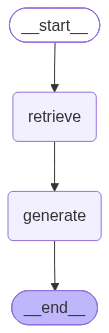

In [42]:
from IPython.display import Image, display

# 시퀀셜하게 나온다
display(Image(graph.get_graph().draw_mermaid_png()))

### 시퀀스 에이전트를 다르게 구축하는 방법

In [43]:
# SateGraph에 [retrieve, generate] 라는 시퀀스가 등록됨
sequence_graph_builder = StateGraph(AgentState).add_sequence([retrieve, generate])

In [44]:
# 원래는 3개로 add_edge를 해도 되지만, 
# 시퀀스를 등록했으므로 중간 과정 add_edge가 제외되어도 상관없다

# sequence_graph_builder.add_edge(START, retrieve)
# sequence_graph_builder.add_edge(retrieve, generate)
# sequence_graph_builder.add_edge(generate, END)

sequence_graph_builder.add_edge(START, 'retrieve')
sequence_graph_builder.add_edge('generate', END)

In [45]:
sequence_graph = sequence_graph_builder.compile()

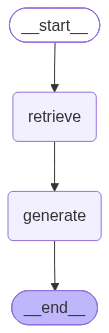

In [46]:
display(Image(sequence_graph.get_graph().draw_mermaid_png()))

In [47]:
# Insight

# sequencial 하게 되어있는 Agent는 두번째 방법처럼 구축하게 되면
# 간단한 코드만으로 구축할 수 있다. (함수명으로 똑같이 노드를 생성할 수 있다)

## 호출

In [48]:
initial_state = {'query': query}
graph.invoke(initial_state)  # gpt가 아닌 로컬 모델 -> 생성 시간이 오래걸린다.

{'query': '연봉 5천만원 직장인의 소득세는?',
 'context': [Document(id='3bb2a976-0d17-42e6-8276-aab868945dcd', metadata={'source': '../documents/output_docs/income_tax.txt'}, page_content='| 1,400만원 이하               | 16퍼센트                                                            |\n| 1,400만원 초과               | 224만원 + (1,400만원 초과액 × 25퍼센트)                                  |\n| 5,000만원 이하               |                                                                     |\n| 5,000만원 초과               | 1,124만원 + (5,000만원 초과액 × 34퍼센트)                                |\n| 8,800만원 이하               |                                                                     |\n| 8,800만원 초과               | 2,416만원 + (8,800만원 초과액 × 45퍼센트)                                |\n| 1억5천만원 이하               |                                                                     |\n| 1억5천만원 초과               | 5,206만원 + (1억5천만원 초과액 × 48퍼센트)                              |\n| 3억원 이하                   |                         

In [ ]:
# Insights

"""
문서를 retrieve 해서 context를 제공한다해도, 제대로된 답변이 안나올 수 있다. (아무리 좋은 모델 gpt-4o계열 등등을 사용하더라도)
# 예를 들면 "죄송하지만, 제공된 문서에는 연봉 5천만원 직장인의 소득세를 구체적으로 계산할 수 있는 정보가 없습니다.~~" 혹은 "연봉 5천만원 직장인의 소득세는 1억 7,406만원입니다 (잘못된 정보)" 등
# 위와 같은 현상이 발생하는 이유는, 사용자의 질문이 문서를 반환할 때 효율이 떨어지는 질문이기 때문일 가능성이 높다 -> 엉뚱한 문서를 반환할 경우

이러한 문제는 conditional edge를 활용해서 사용자의 질문을 rewrite 하고, 올바른 문서를 반환하는 방법을 활용해야 한다. (다음 노트북)
"""


```text
                                      관련 문서 있음
                                ─────────────────────▶ ┌────────────┐     ┌───────┐
                              ╱                        │  generate  │────▶│  END  │
                             ╱                         └────────────┘     └───────┘
┌─────────┐     ┌────────────┐
│  START  │────▶│  retrieve  │
└─────────┘     └────────────┘
                    ▲        ╲
                    │         ╲ 검색 결과 부족 ──────▶ ┌────────────┐
                    │                                  │  rewrite   │
                    └──────────────────────────────────┴────────────┘
                                     재검색
```